In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# from scipy.signal import TransferFunction, tf2zpk

In [2]:
def generate_psd(f, cutoff, n, turb_power, noise_power):
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, (f_safe / cutoff)**(-2/3), (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
        
    df = np.gradient(f)
    f_s = f[-1] * 2 
    sinc_filter = np.sinc(f_safe / f_s)**2 
    psd_turb *= sinc_filter
    
    psd_turb *= (turb_power / np.sum(psd_turb * df))
    
    psd_noise = np.ones_like(f)
    psd_noise *= (noise_power / np.sum(psd_noise * df))
    
    return psd_turb, psd_noise

def eval_tf(b, a, f, f_s):
    z_inv = np.exp(-1j * 2 * np.pi * f / f_s)
    num = sum(b[k] * (z_inv**k) for k in range(len(b)))
    den = sum(a[k] * (z_inv**k) for k in range(len(a)))
    return num / den

def is_stable(a):
    roots = np.roots(a)
    return np.all(np.abs(roots) < 0.9999)

def pre_fit_controller(order, f, psd_turb, f_s):
    target_mag = np.sqrt(psd_turb)
    target_mag /= np.max(target_mag)
    
    def loss(params):
        b = params[:order+1]
        a = np.insert(params[order+1:], 0, 1.0)
        if not is_stable(a): return 1e6
        C = eval_tf(b, a, f, f_s)
        return np.sum((np.abs(C) - target_mag)**2)

    init_b = np.zeros(order + 1); init_b[0] = 0.1
    init_a = np.zeros(order); init_a[0] = -0.9
    init_params = np.concatenate([init_b, init_a])

    res = minimize(loss, init_params, method='Nelder-Mead', options={'maxiter': 5000})
    b_guess = res.x[:order+1]
    a_guess = np.insert(res.x[order+1:], 0, 1.0)
    return b_guess, a_guess

def cost_function(params, order, f, psd_turb, psd_noise, N, f_s, og=1.0):
    b = params[:order+1]
    a = np.insert(params[order+1:], 0, 1.0)
    if not is_stable(a): return 1e9 

    C = eval_tf(b, a, f, f_s)
    P = np.exp(-1j * 2 * np.pi * f * N / f_s)
    H_ol = C * P
    denom = 1.0 + H_ol*og
    if np.min(np.abs(denom)) < 1e-4: return 1e9

    RTF = 1.0 / denom
    NTF = H_ol / denom
    psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
    return np.sum(psd_res * np.gradient(f))

def optimize_higher_order_scao(orders=[1, 2, 3], turb_power=100.0, noise_power=0.5, og=1.0, show:bool=False,
                               delay_steps=1.5, loop_freq=1000.0, cutoff=15.0, n=1, restarts:int=100):
    
    f_s = loop_freq
    f = np.linspace(0.1, f_s/2.0, 2000)
    psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)

    var = []
    a_coeffs = []
    b_coeffs = []
    
    if show:
        plt.figure(figsize=(16, 6))
        plt.subplot(1, 2, 1)
        plt.loglog(f, psd_turb/psd_noise, label=f'Turbulence PSD (n={n})')
        plt.loglog(f, psd_noise/psd_noise, '--',label='Noise Floor')
        plt.subplot(1, 2, 2)
        plt.loglog(f, psd_turb, label='Uncorrected Turb')
        plt.loglog(f, psd_noise, '--', label='Noise floor')
    
    for i, order in enumerate(orders):
        b_guess, a_guess = pre_fit_controller(order, f, psd_turb, f_s)
        init_params = np.concatenate([b_guess, a_guess[1:]])
        
        res = minimize(cost_function, init_params, 
                       args=(order, f, psd_turb, psd_noise, delay_steps, f_s, og),
                       method='Nelder-Mead', 
                       options={'maxiter': 5000, 'adaptive': True})
        
        best_b = res.x[:order+1]
        best_a = np.insert(res.x[order+1:], 0, 1.0)
        
        C = eval_tf(best_b, best_a, f, f_s)
        P = np.exp(-1j * 2 * np.pi * f * delay_steps / f_s)
        H_ol = C * P
        den = 1.0 + H_ol*og
        RTF = 1.0 / den
        NTF = H_ol / den
        
        psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
        min_variance = np.sum(psd_res * np.gradient(f))

        var.append(min_variance)
        a_coeffs.append(best_a)
        b_coeffs.append(best_b)
        
        if show:
            print(f"Order {order}:")
            print(f" B coefficients: {best_b}")
            print(f" A coefficients: {best_a}")
            print(f" Residual Variance: {min_variance:.4e}\n")
            
            plt.subplot(1, 2, 1)
            plt.loglog(f, 1.0/(np.abs(RTF)**2), label=r'$|RTF|^-2$'+f' (Order {order})')
            plt.subplot(1, 2, 2)
            plt.loglog(f, psd_res, label=f'Residual (Order {order})')

    if show:
        plt.subplot(1, 2, 1)
        plt.title(f"Spectral SNR")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power / Amplitude")
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.xlim(f[0], f[-1])
        plt.ylim([1e-2,psd_turb[0]/psd_noise[0]*4])
        
        plt.subplot(1, 2, 2)
        plt.title(f"Residual PSD")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power Spectral Density")
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.xlim(f[0], f[-1])
        plt.ylim([1e-2*psd_noise[0],psd_turb[0]*4])

        plt.tight_layout()

    return np.array(var), np.array(best_a), np.array(best_b)
    

    


Order 1:
 B coefficients: [0.25419602 0.02325097]
 A coefficients: [ 1.         -0.99692684]
 Residual Variance: 3.0460e-01

Order 2:
 B coefficients: [0.19845286 0.02998259 0.02379857]
 A coefficients: [ 1.         -1.1151179   0.11802738]
 Residual Variance: 2.9650e-01

Order 3:
 B coefficients: [ 0.17824679 -0.10980516  0.005061   -0.03311288]
 A coefficients: [ 1.         -1.18079567 -0.57308409  0.75495664]
 Residual Variance: 2.2773e-01

Order 4:
 B coefficients: [ 0.17734896  0.02531747 -0.10022172 -0.06407871  0.01895331]
 A coefficients: [ 1.         -0.85179787 -0.7643027   0.16581162  0.45182073]
 Residual Variance: 2.1122e-01



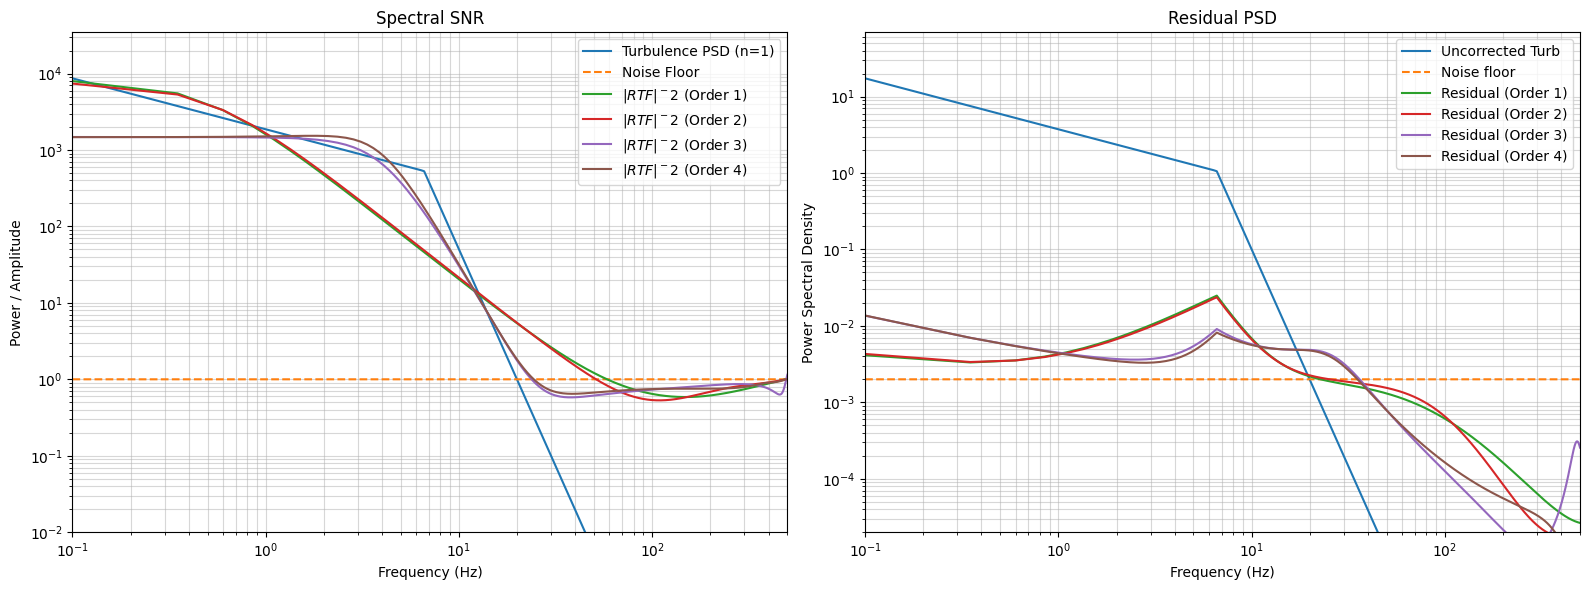

In [3]:
D = 1.82 #8.4 #
v = 20.0 
n = 1
f_break_n2 = 0.3 * (n + 1) * v / D 
f = 1000 #1700 #
delay = 1.5 #3.5
opt_gain = 1.0
SNR = 20

var, a, b = optimize_higher_order_scao(
    orders=[1, 2, 3, 4],
    turb_power=SNR,
    noise_power=1.0,
    delay_steps=delay,
    loop_freq=f,
    cutoff=f_break_n2,
    n=n,
    og=opt_gain,
    show = True
)

In [4]:
from astropy.io import fits
import os.path as op
# import matplotlib.pyplot as plt
from specula.mmlib.utils import get_pupil_mask, radial_order

def rec_ron_cov(rec,frame,mask,flux=None):
    if flux is None:
        flux = np.sum(frame)
    norm = np.mean(frame[mask.astype(bool)])
    norm_rec = rec / (norm / flux)
    rec_cov = norm_rec @ norm_rec.T
    return np.diag(rec_cov)

def rec_shot_cov(rec,frame,mask,sn,flux=None):
    if flux is None:
        flux = np.sum(frame)
    norm = np.mean(frame[mask.astype(bool)])
    phot_noise = np.diag(sn/ (norm / flux))
    rec_cov = rec @ phot_noise @ rec.T
    return np.diag(rec_cov)

def rec_noise(shot_cov,ron_cov, RON=0.5, Nphot=1e+6):
    sigma = ron_cov * RON/Nphot**2 + shot_cov / Nphot
    return sigma

def von_karman_power(k,r0,L0):
    C = 0.02289558710855519
    B = k**2 + (1/L0)**2
    return C * r0**(-5.0/3.0) * B**(-11.0/6.0)

def get_radial_order_vector(N:int):
    return np.hstack([np.repeat(i,i) for i in range(2,N+1)])

root_dir = '/raid1/mmenessini/calibration/EKARUS'


Cupy import successfull. Installed version is: 14.0.1
Default device is GPU number  0


In [5]:
ccd_size = 120
rec = fits.getdata(op.join(root_dir,'rec/pyr5.0_40x40_400modes_rec.fits'))
frame = fits.getdata(op.join(root_dir,'frames/pyr5.0_40x40_frame_null.fits'))[0]
pyr_mask = get_pupil_mask(npix=ccd_size, filepath=op.join(root_dir,'pupils/pyr_pupdata_40x40.fits'), pyr=True)
sn = fits.getdata(op.join(root_dir,'slopenulls/pyr5.0_40x40_sn.fits'))

# plt.figure()
# plt.plot(sn)
# plt.grid()

# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.imshow(frame/np.max(frame),origin='lower',cmap='RdBu')
# plt.colorbar()
# plt.subplot(1,2,2)
# plt.imshow(pyr_mask,origin='lower',cmap='gray')
# plt.colorbar()

In [6]:
ron_cov = rec_ron_cov(rec,frame,pyr_mask)
shot_cov = rec_shot_cov(rec,frame,pyr_mask,sn)

x = np.arange(len(ron_cov))+1

modal_basis = fits.getdata(op.join(root_dir,'ifunc','dm468_kl_inv.fits'))
pupil_mask = (1-fits.getdata(op.join(root_dir,'pupilstop','copernico_pupil_120pixels.fits'))).astype(bool)


# plt.figure(figsize=(12,4))
# plt.subplot(1,2,1)
# plt.loglog(x,ron_cov)
# plt.grid(which='both',alpha=0.4)
# plt.subplot(1,2,2)
# plt.loglog(x,shot_cov)
# plt.grid(which='both',alpha=0.4)


In [7]:
def compute_modal_variance_von_karman(r0, L0, D, modes, mask):
    """
    Computes the turbulent power projected on a given modal basis 
    assuming a Von Karman phase power spectrum.
    
    Parameters:
    - r0: float, Fried parameter [m]
    - L0: float, Outer scale [m]
    - D: float, Telescope diameter [m]
    - modes: 3D numpy array of shape (N_modes, N_pixels, N_pixels) containing the modal basis
    - mask: 2D numpy array of shape (N_pixels, N_pixels) representing the telescope pupil
    
    Returns:
    - modal_variances: 1D numpy array of length N_modes containing the variance 
                       (turbulent power) of each mode [rad^2]
    """
    n_modes = modes.shape[0] 
    nx, ny = mask.shape
    
    # Assuming the grid spans the telescope diameter exactly
    # Pixel scale in the pupil plane [m/pixel]
    dx = D / nx  
    dy = D / ny
    
    # Generate spatial frequency grids [1/m]
    fx = np.fft.fftfreq(nx, d=dx)
    fy = np.fft.fftfreq(ny, d=dy)
    FX, FY = np.meshgrid(fx, fy)
    
    # Squared spatial frequency magnitude
    F2 = FX**2 + FY**2
    
    # Von Karman phase power spectrum (Phi(f) in [rad^2 * m^2])
    # Formula: Phi_VK(f) = 0.0229 * r0^(-5/3) * (f^2 + (1/L0)^2)^(-11/6)
    phi_vk = 0.0229 * (r0 ** (-5/3)) * (F2 + (1.0 / L0)**2) ** (-11/6)
    
    # Frequency grid step sizes for integration [1/m]
    dfx = 1.0 / (nx * dx)
    dfy = 1.0 / (ny * dy)
    
    modal_variances = np.zeros(n_modes)
    mode_masked = np.zeros_like(mask,dtype=float)
    
    for i in range(n_modes):
        # Apply the telescope pupil mask to the mode
        mode_masked[~mask] = modes[i,:]/np.std(modes[i,:])
        
        # Continuous Fourier Transform approximation of the mode
        # Mode is in spatial domain, multiplied by pixel area (dx*dy) to scale the FFT appropriately
        mode_fft = np.fft.fft2(mode_masked) * (dx * dy)
        
        # Power Spectral Density of the mode |M(f)|^2
        mode_psd = np.abs(mode_fft) ** 2
        
        # Integrate the multiplication of the mode PSD and the Von Karman PSD 
        # over the spatial frequency space: integral(|M(f)|^2 * Phi(f) dfx dfy)
        modal_variances[i] = np.sum(mode_psd * phi_vk) * (dfx * dfy)
        
    return modal_variances



Text(0.5, 1.0, 'Flux: 284.9 ph/subap/frame')

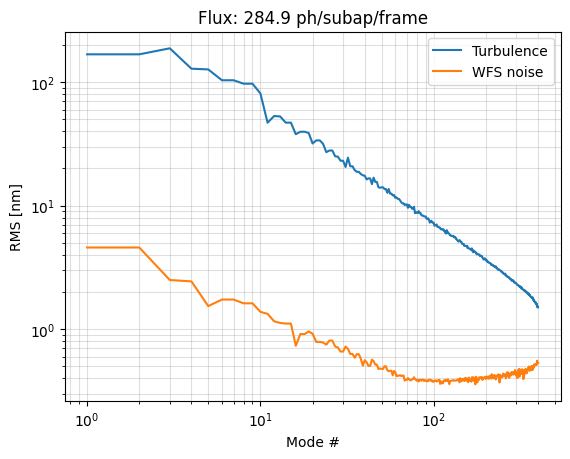

In [14]:
r0 = 0.1
L0 = 25
lambdaInNm = 750

mag = 1
thrp = 0.06
D = 1.82
fs = 1000
A = np.pi*D**2/4
Nphot = A * 1e+10 * 10**(-mag/2.5) * thrp * 1/fs
wfs_noise2 = rec_noise(ron_cov=ron_cov,shot_cov=shot_cov,RON=0.4,Nphot=Nphot)
wfs_noise = np.sqrt(wfs_noise2)

modes_cov = compute_modal_variance_von_karman(r0=r0,L0=L0,D=D,modes=modal_basis,mask=pupil_mask)
modesInNm = (np.sqrt(modes_cov)/A * lambdaInNm/(2*np.pi))

SNR = modesInNm[:len(x)]/wfs_noise

plt.figure()
plt.loglog(x,modesInNm[:len(x)],label='Turbulence')
plt.loglog(x,wfs_noise,label='WFS noise')
plt.grid(which='both',alpha=0.4)
plt.xlabel('Mode #')
plt.ylabel('RMS [nm]')
plt.legend()
plt.title(f'Flux: {Nphot/(np.sum(1-pyr_mask)/4):1.1f} ph/subap/frame')


In [ ]:
N = len(SNR)
orders = [1,3]
D = 1.82
v = 20.0 
f = 1000 #1700 #
delay = 1.5 #3.5

var = np.zeros([N,len(orders)])
best_num = np.zeros([N,np.max(orders)])
best_den = np.zeros([N,np.max(orders)])

for j in range(N):
    n_rad = radial_order(j)
    f_cutoff = 0.3 * (n_rad + 1) * v / D 
    var[j,:], num, den = optimize_higher_order_scao(
        orders=orders,
        turb_power=SNR[j],
        noise_power=1.0,
        delay_steps=delay,
        loop_freq=f,
        cutoff=f_cutoff,
        n=n_rad
    )
    best_num[j,:] = num[-np.max(orders)-1:-1]
    best_den[j,:] = den[-np.max(orders)-1:-1]

22.89180155844454 20.5244152940525


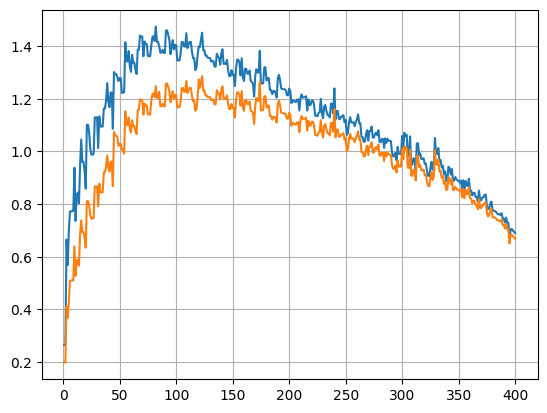

In [ ]:

ff_rms = np.sqrt(np.sum(var[:,0]**2))
iir_rms = np.sqrt(np.sum(var[:,1]**2))

plt.figure()
plt.plot(x,var[:,0],label=f'RMS {ff_rms:1.1f} [nm]')
plt.plot(x,var[:,1],label=f'RMS {iir_rms:1.1f} [nm]')
plt.legend()
plt.grid()